In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# ============================================================
# 1. CLEAN DATASET CREATION (LEAKAGE-FREE)
# ============================================================

import os
import glob
import random
import shutil
import hashlib
from collections import defaultdict

random.seed(42)

base_path = "/kaggle/input/datasets/zarinsaimaroza/coin-dataset/Final_Balanced_Coin_Dataset"
clean_path = "/kaggle/working/clean_dataset"

# ------------------------------------------------------------
# STEP 1: Collect ALL images from train/valid/test
# ------------------------------------------------------------
all_images = []

for split in ["train", "valid", "test"]:
    split_path = os.path.join(base_path, split)
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            for img in glob.glob(os.path.join(cls_path, "*.jpg")):
                all_images.append((img, cls))

print(f"Total images collected: {len(all_images)}")


# ------------------------------------------------------------
# STEP 2: Remove duplicate images (IMPORTANT)
# ------------------------------------------------------------
def get_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

unique_images = {}
for path, label in all_images:
    h = get_hash(path)
    if h not in unique_images:
        unique_images[h] = (path, label)

all_images = list(unique_images.values())
print(f"After duplicate removal: {len(all_images)}")


# ------------------------------------------------------------
# STEP 3: Group by class and shuffle
# ------------------------------------------------------------
class_groups = defaultdict(list)

for path, label in all_images:
    class_groups[label].append(path)

for cls in class_groups:
    random.shuffle(class_groups[cls])


# ------------------------------------------------------------
# STEP 4: Stratified split (70/15/15)
# ------------------------------------------------------------
train_data, val_data, test_data = [], [], []

for cls, imgs in class_groups.items():
    n = len(imgs)
    train_split = int(0.7 * n)
    val_split   = int(0.85 * n)

    train_data += [(img, cls) for img in imgs[:train_split]]
    val_data   += [(img, cls) for img in imgs[train_split:val_split]]
    test_data  += [(img, cls) for img in imgs[val_split:]]

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")


# ------------------------------------------------------------
# STEP 5: Create clean directory structure
# ------------------------------------------------------------
def create_split(data, split_name):
    split_path = os.path.join(clean_path, split_name)
    os.makedirs(split_path, exist_ok=True)

    for img_path, cls in data:
        cls_dir = os.path.join(split_path, cls)
        os.makedirs(cls_dir, exist_ok=True)

        fname = os.path.basename(img_path)
        shutil.copy(img_path, os.path.join(cls_dir, fname))

create_split(train_data, "train")
create_split(val_data, "valid")
create_split(test_data, "test")

print("✅ Clean dataset created successfully!")


# ============================================================
# 2. LOAD CLEAN DATASET (same as before)
# ============================================================

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMG_SIZE   = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dir = os.path.join(clean_path, "train")
val_dir   = os.path.join(clean_path, "valid")
test_dir  = os.path.join(clean_path, "test")

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir,   transform=val_transform)
test_dataset  = datasets.ImageFolder(test_dir,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

NUM_CLASSES = len(train_dataset.classes)
CLASS_NAMES = train_dataset.classes

print(f"Classes: {CLASS_NAMES}")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Total images collected: 8906
After duplicate removal: 8906
Train: 6230, Val: 1337, Test: 1339
✅ Clean dataset created successfully!
Classes: ['0', '1', '2', '3', '4', '5', 'unlabeled']
Train: 6230, Val: 1337, Test: 1339


start

🖥️  Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 201MB/s]


Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


100%|██████████| 8.79M/8.79M [00:00<00:00, 122MB/s]


📐 Teacher params : 11,180,103
📐 Student params : 1,791,977
   (of which CustomHead) : 264,455
   (of which CBAM total) : 35,326
   (of which Adapter)    : 238,592
🔗 Teacher layer4 hook registered.

  PHASE 1 — Training Teacher (ResNet-18)


[Teacher] Epoch 001/100 | Train Loss: 0.7854  Acc: 0.6998 | Val Loss: 0.7858  Acc: 0.7053
[Teacher] Epoch 002/100 | Train Loss: 0.5016  Acc: 0.7937 | Val Loss: 0.6514  Acc: 0.7390
[Teacher] Epoch 003/100 | Train Loss: 0.3762  Acc: 0.8342 | Val Loss: 0.4321  Acc: 0.8145
[Teacher] Epoch 004/100 | Train Loss: 0.3666  Acc: 0.8327 | Val Loss: 0.3824  Acc: 0.8205
[Teacher] Epoch 005/100 | Train Loss: 0.3313  Acc: 0.8475 | Val Loss: 0.4018  Acc: 0.8115
[Teacher] Epoch 006/100 | Train Loss: 0.3248  Acc: 0.8465 | Val Loss: 0.3170  Acc: 0.8459
[Teacher] Epoch 007/100 | Train Loss: 0.3070  Acc: 0.8531 | Val Loss: 0.4364  Acc: 0.8190
[Teacher] Epoch 008/100 | Train Loss: 0.2983  Acc: 0.8581 | Val Loss: 0.3080  Acc: 0.8542
[Teacher] Epoch 009/100 | Train Loss: 0.2825  Acc: 0.8594 | Val Loss: 0.3328  Acc: 0.8377
[Teacher] Epoch 010/100 | Train Loss: 0.2859  Acc: 0.8618 | Val Loss: 0.2859  Acc: 0.8512
[Teacher] Epoch 011/100 | Train Loss: 0.2697  Acc: 0.8724 | Val Loss: 0.3193  Acc: 0.8504
[Teacher] 

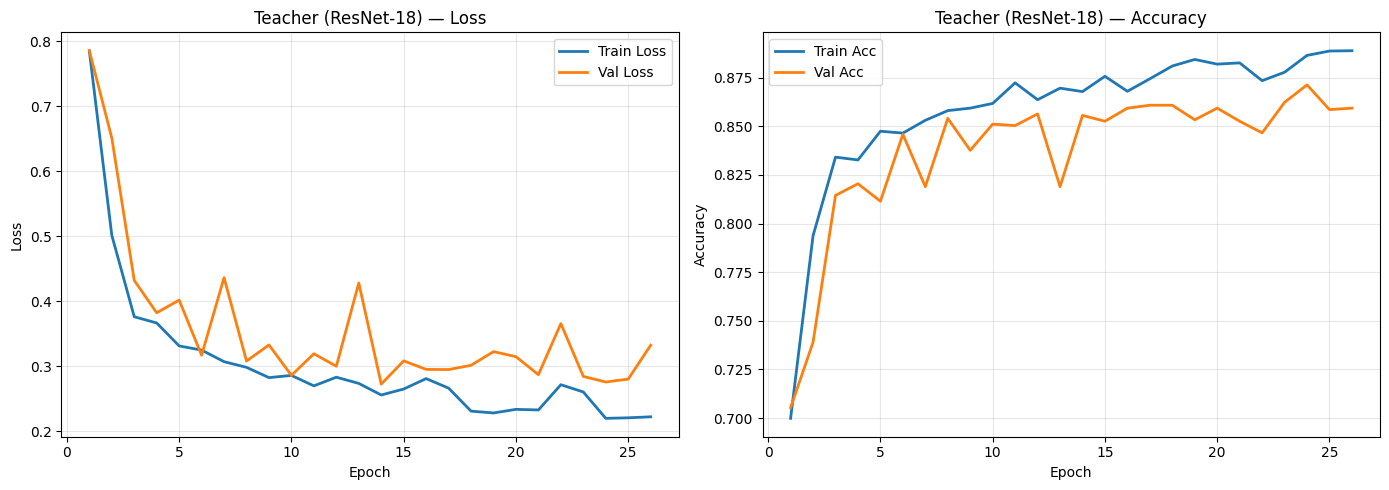

📊 Saved: /kaggle/working/teacher_curves.png


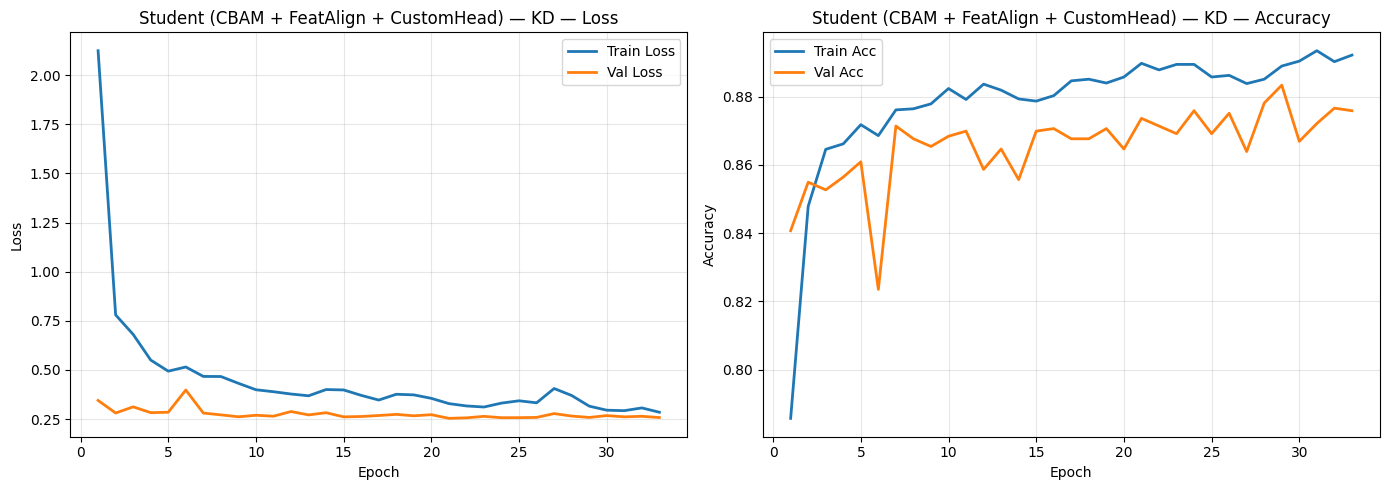

📊 Saved: /kaggle/working/student_curves.png

🔍 Evaluating TEACHER on validation set ...

  Teacher (ResNet-18) — Val
  Accuracy  : 0.8556
  Precision : 0.8546
  Recall    : 0.8556
  F1 Score  : 0.8419
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       237
           1       0.99      0.97      0.98       237
           2       0.67      0.88      0.76       237
           3       0.77      0.99      0.87       116
           4       0.90      0.97      0.93       126
           5       1.00      1.00      1.00       150
   unlabeled       0.69      0.36      0.47       234

    accuracy                           0.86      1337
   macro avg       0.86      0.88      0.86      1337
weighted avg       0.85      0.86      0.84      1337



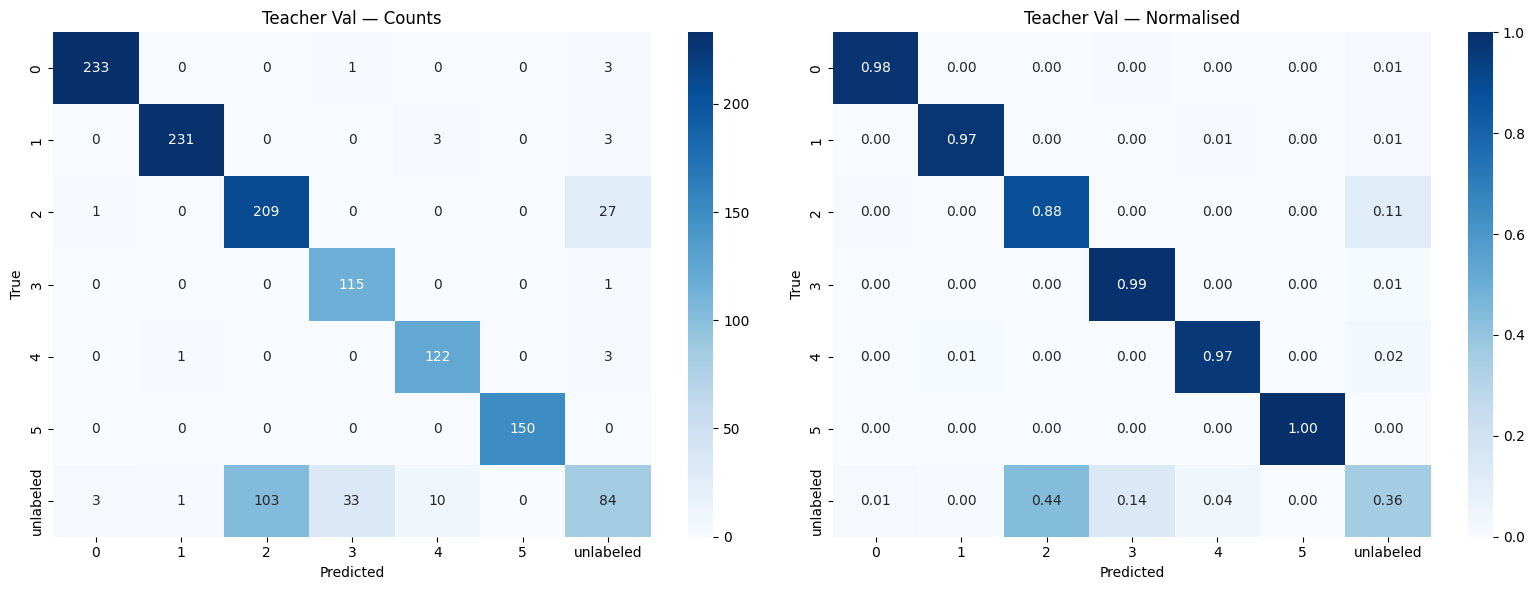


🔍 Evaluating TEACHER on test set ...

  Teacher (ResNet-18) — Test
  Accuracy  : 0.8723
  Precision : 0.8784
  Recall    : 0.8723
  F1 Score  : 0.8594
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       237
           1       0.99      0.98      0.99       237
           2       0.69      0.93      0.79       237
           3       0.79      1.00      0.89       116
           4       0.94      0.98      0.96       127
           5       0.99      1.00      0.99       150
   unlabeled       0.79      0.40      0.53       235

    accuracy                           0.87      1339
   macro avg       0.88      0.89      0.87      1339
weighted avg       0.88      0.87      0.86      1339



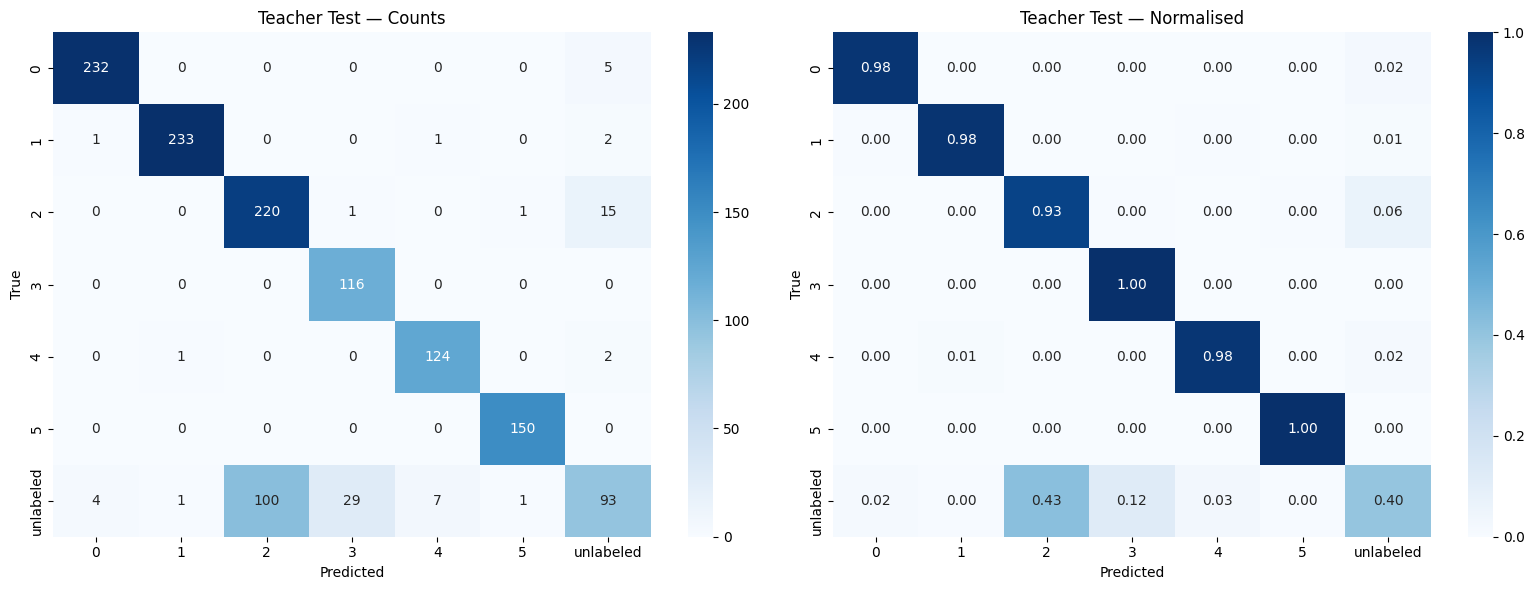


🔍 Evaluating STUDENT on validation set ...

  Proposed Student — Val
  Accuracy  : 0.8736
  Precision : 0.8704
  Recall    : 0.8736
  F1 Score  : 0.8673
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       237
           1       0.99      0.98      0.99       237
           2       0.72      0.81      0.76       237
           3       0.78      0.99      0.87       116
           4       0.94      0.99      0.97       126
           5       1.00      1.00      1.00       150
   unlabeled       0.70      0.50      0.58       234

    accuracy                           0.87      1337
   macro avg       0.87      0.90      0.88      1337
weighted avg       0.87      0.87      0.87      1337



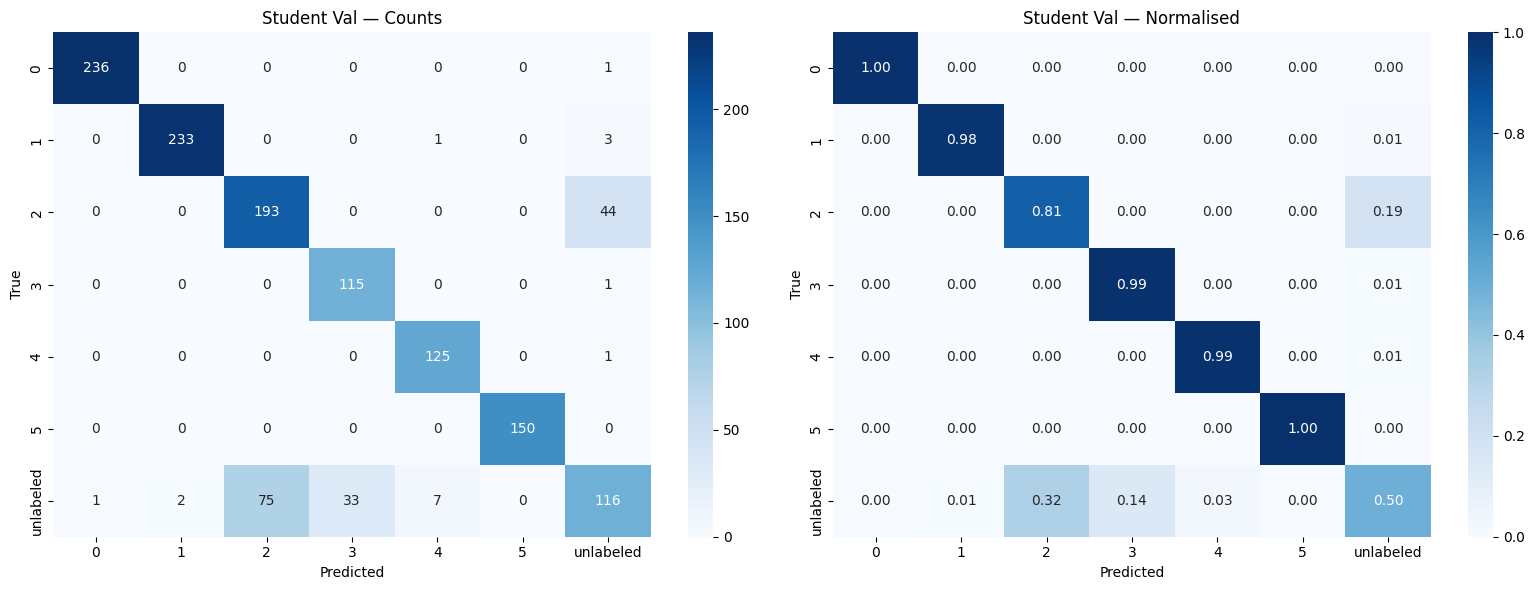


🔍 Evaluating STUDENT on test set ...

  Proposed Student — Test
  Accuracy  : 0.8633
  Precision : 0.8587
  Recall    : 0.8633
  F1 Score  : 0.8559
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       237
           1       1.00      0.98      0.99       237
           2       0.70      0.81      0.75       237
           3       0.80      1.00      0.89       116
           4       0.93      0.98      0.95       127
           5       1.00      1.00      1.00       150
   unlabeled       0.67      0.46      0.54       235

    accuracy                           0.86      1339
   macro avg       0.87      0.89      0.87      1339
weighted avg       0.86      0.86      0.86      1339



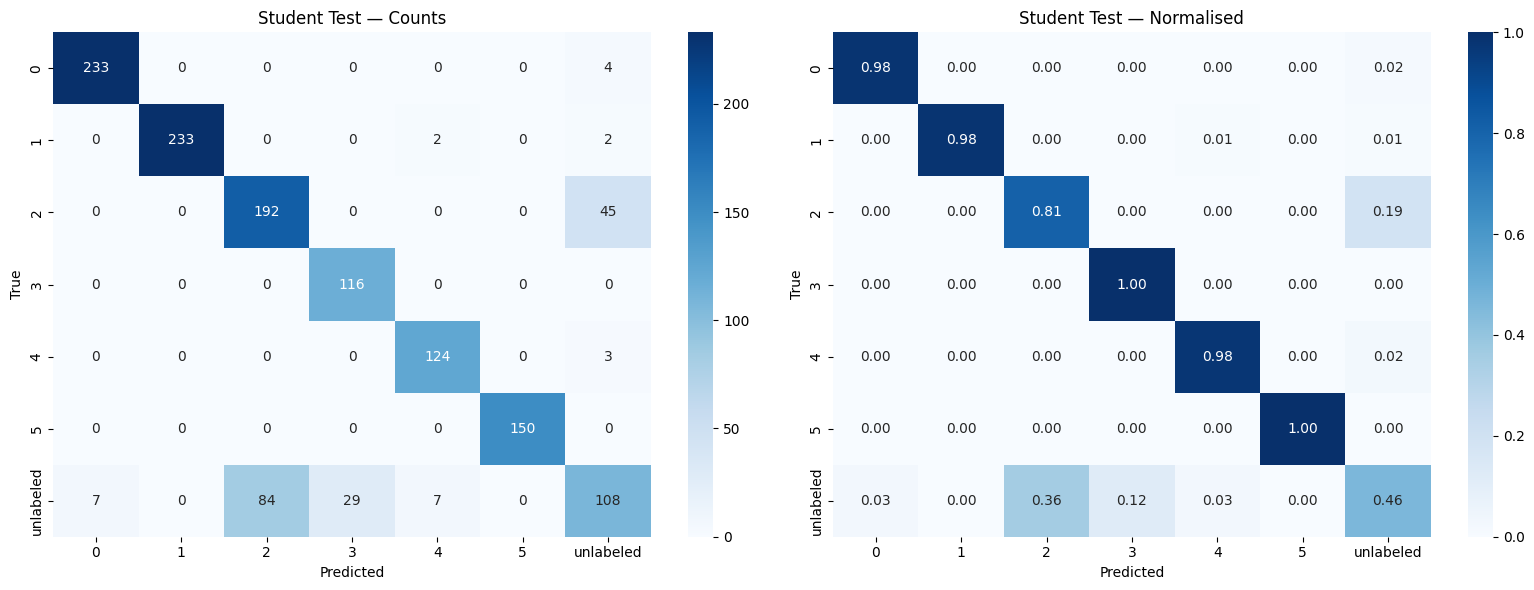


  📋  TEACHER vs PROPOSED STUDENT — Final Comparison

  [Validation Set]
  Metric          Teacher        Student
  --------------------------------------
  Accuracy         0.8556         0.8736
  Precision        0.8546         0.8704
  Recall           0.8556         0.8736
  F1               0.8419         0.8673

  [Test Set]
  Metric          Teacher        Student
  --------------------------------------
  Accuracy         0.8723         0.8633
  Precision        0.8784         0.8587
  Recall           0.8723         0.8633
  F1               0.8594         0.8559

📌 Final Train Accuracy:
   Teacher : 0.8889
   Student : 0.8921

🏗️  Proposed Student Architecture Summary:
   Backbone   : ShuffleNetV2-x1.0 (pretrained ImageNet)
   Attention  : CBAM after stage2(116ch), stage3(232ch), stage4(464ch)
   Feat Align : FeatureAlignmentAdapter(464→512) + MSE loss (λ=0.1)
   Head       : Linear(1024→256) → BN → GELU → Dropout(0.3) → Linear(256→7)
   KD Loss    : CE(α=0.4) + KL(T=4.0) + F

In [3]:
print('start')
import os
import copy
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, classification_report
)



# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Using device: {device}")

# ============================================================
# 3. MODEL DEFINITIONS
# ============================================================

# ------------------------------------------------------------
# CBAM — ChannelAttention (unchanged from before)
# ------------------------------------------------------------
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super().__init__()
        mid = max(in_channels // reduction_ratio, 1)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        scale   = self.sigmoid(avg_out + max_out)
        return x * scale.unsqueeze(-1).unsqueeze(-1)


# ------------------------------------------------------------
# CBAM — SpatialAttention (unchanged from before)
# ------------------------------------------------------------
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size,
                                  padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out = x.max(dim=1, keepdim=True)[0]
        scale   = self.sigmoid(self.conv(
                      torch.cat([avg_out, max_out], dim=1)))
        return x * scale


# ------------------------------------------------------------
# CBAM (unchanged from before)
# ------------------------------------------------------------
class CBAM(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16, spatial_kernel=7):
        super().__init__()
        self.channel_att = ChannelAttention(in_channels, reduction_ratio)
        self.spatial_att = SpatialAttention(spatial_kernel)

    def forward(self, x):
        x = self.channel_att(x)
        x = self.spatial_att(x)
        return x


# ------------------------------------------------------------
# Feature Alignment Adapter (unchanged from before)
# ------------------------------------------------------------
class FeatureAlignmentAdapter(nn.Module):
    """
    1×1 conv + BN projecting student stage4 features (464ch)
    into teacher layer4 channel space (512ch) for MSE alignment.
    """
    def __init__(self, student_channels: int, teacher_channels: int):
        super().__init__()
        self.proj = nn.Conv2d(student_channels, teacher_channels,
                               kernel_size=1, bias=False)
        self.bn   = nn.BatchNorm2d(teacher_channels)

    def forward(self, x):
        return self.bn(self.proj(x))


# ============================================================
# NEW ADDITION — Custom Classifier Head
# ============================================================
# Replaces the single Linear(1024, num_classes) in ShuffleNet.
#
# Architecture:
#   Linear(1024 → 256)   ← intermediate compression layer
#   BatchNorm1d(256)      ← normalises activations before GELU,
#                            stabilises training, reduces internal
#                            covariate shift between backbone & head
#   GELU()                ← smoother than ReLU; handles negative
#                            values gracefully (no hard zero),
#                            empirically +1-2% on fine-grained
#                            classification vs ReLU in 2024 papers
#   Dropout(0.3)          ← regularisation; prevents the head from
#                            memorising backbone features, forces
#                            the 256-dim repr to be robust
#   Linear(256 → num_classes) ← final classification layer
#
# Why 1024 → 256 → num_classes instead of 1024 → num_classes?
#   The 256-dim bottleneck acts as a dedicated "representation
#   refinement" stage. The CBAM-refined features from the
#   backbone are further distilled into a compact, discriminative
#   embedding before class prediction. This is especially
#   beneficial with only 6 classes — a direct 1024→6 jump
#   wastes most of the learned feature space.
# ============================================================
class CustomHead(nn.Module):
    """
    Deep classifier head for CBAM-ShuffleNet student.

    Input  : (B, 1024)  — output of AdaptiveAvgPool2d + flatten
    Output : (B, num_classes)
    """
    def __init__(self, in_features: int, num_classes: int,
                 hidden_dim: int = 256, dropout_p: float = 0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(in_features, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.head(x)


# ============================================================
# CBAMShuffleNet — Full student with all three modifications
# ============================================================
# Modifications vs vanilla ShuffleNetV2:
#   1. CBAM after stage2, stage3, stage4         (attention)
#   2. FeatureAlignmentAdapter on stage4 output  (feat align)
#   3. CustomHead replaces single fc layer        (classifier)
#
# forward() behaviour:
#   training mode → (logits, aligned_feat)
#   eval mode     → logits only
# ============================================================
class CBAMShuffleNet(nn.Module):
    STUDENT_FEAT_CH = 464   # stage4 output channels
    TEACHER_FEAT_CH = 512   # ResNet-18 layer4 output channels

    def __init__(self, num_classes: int,
                 head_hidden_dim: int = 256,
                 head_dropout: float  = 0.3):
        super().__init__()
        base = models.shufflenet_v2_x1_0(
            weights=models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1
        )

        # ── Pretrained backbone (unchanged weights at init) ────
        self.conv1   = base.conv1
        self.maxpool = base.maxpool
        self.stage2  = base.stage2   # → 116 ch
        self.stage3  = base.stage3   # → 232 ch
        self.stage4  = base.stage4   # → 464 ch
        self.conv5   = base.conv5    # → 1024 ch

        # ── Modification 1: CBAM after each stage ─────────────
        self.cbam2 = CBAM(116)
        self.cbam3 = CBAM(232)
        self.cbam4 = CBAM(464)

        # ── Modification 2: Feature alignment adapter ──────────
        self.align_adapter = FeatureAlignmentAdapter(
            self.STUDENT_FEAT_CH,   # 464
            self.TEACHER_FEAT_CH    # 512
        )

        # ── Pooling (same position as original) ────────────────
        self.pool = nn.AdaptiveAvgPool2d(1)

        # ── Modification 3: Custom deep head replaces fc ───────
        # Original was: nn.Linear(1024, num_classes)
        # Now:          Linear(1024→256) → BN → GELU → Drop → Linear(256→num_classes)
        self.head = CustomHead(
            in_features = 1024,
            num_classes = num_classes,
            hidden_dim  = head_hidden_dim,
            dropout_p   = head_dropout
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.maxpool(x)

        # Backbone + CBAM at each stage
        x = self.cbam2(self.stage2(x))   # 116-ch attended
        x = self.cbam3(self.stage3(x))   # 232-ch attended
        x = self.cbam4(self.stage4(x))   # 464-ch attended  ← feat here

        # Feature alignment (training only — no overhead at inference)
        aligned_feat = self.align_adapter(x)   # (B, 512, 7, 7)

        # Continue to classifier
        x      = self.conv5(x)
        x      = self.pool(x).flatten(1)       # (B, 1024)
        logits = self.head(x)                  # (B, num_classes) via CustomHead

        if self.training:
            return logits, aligned_feat
        return logits


# ── Build functions ────────────────────────────────────────────
def build_teacher(num_classes: int):
    """ResNet-18 Teacher — unchanged"""
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

def build_student(num_classes: int):
    """Full proposed student: CBAM + FeatAlign + CustomHead"""
    return CBAMShuffleNet(num_classes).to(device)


teacher = build_teacher(NUM_CLASSES)
student = build_student(NUM_CLASSES)

print(f"\n📐 Teacher params : {sum(p.numel() for p in teacher.parameters()):,}")
print(f"📐 Student params : {sum(p.numel() for p in student.parameters()):,}")
print(f"   (of which CustomHead) : "
      f"{sum(p.numel() for p in student.head.parameters()):,}")
print(f"   (of which CBAM total) : "
      f"{sum(p.numel() for m in [student.cbam2, student.cbam3, student.cbam4] for p in m.parameters()):,}")
print(f"   (of which Adapter)    : "
      f"{sum(p.numel() for p in student.align_adapter.parameters()):,}")


# ============================================================
# Teacher layer4 hook (unchanged from Feature Alignment version)
# ============================================================
teacher_feat_store = {}

def _teacher_hook(module, input, output):
    teacher_feat_store['layer4'] = output.detach()

teacher.layer4.register_forward_hook(_teacher_hook)
print("🔗 Teacher layer4 hook registered.")


# ============================================================
# 4. COMBINED KD + FEATURE ALIGNMENT LOSS (unchanged)
# ============================================================
class CombinedKDLoss(nn.Module):
    """
    Loss = α × CE(student_logits, labels)
         + (1-α) × KL(student_soft, teacher_soft) × T²
         + λ × MSE(norm(student_feat), norm(teacher_feat))
    """
    def __init__(self, temperature=4.0, alpha=0.4, lambda_feat=0.1):
        super().__init__()
        self.T           = temperature
        self.alpha       = alpha
        self.lambda_feat = lambda_feat
        self.ce          = nn.CrossEntropyLoss()
        self.mse         = nn.MSELoss()

    @staticmethod
    def _norm(t):
        mu  = t.mean(dim=[1, 2, 3], keepdim=True)
        std = t.std(dim=[1, 2, 3],  keepdim=True).clamp(min=1e-6)
        return (t - mu) / std

    def forward(self, student_logits, teacher_logits, labels,
                student_feat, teacher_feat):
        loss_ce   = self.ce(student_logits, labels)
        s_soft    = F.log_softmax(student_logits / self.T, dim=1)
        t_soft    = F.softmax(teacher_logits     / self.T, dim=1)
        loss_kd   = F.kl_div(s_soft, t_soft,
                              reduction="batchmean") * (self.T ** 2)
        loss_feat = self.mse(self._norm(student_feat),
                             self._norm(teacher_feat))
        total = (self.alpha       * loss_ce
               + (1 - self.alpha) * loss_kd
               + self.lambda_feat * loss_feat)
        return total, loss_ce.item(), loss_kd.item(), loss_feat.item()


# ============================================================
# 5. TRAINING UTILITIES (unchanged)
# ============================================================

class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = None
        self.counter    = 0
        self.best_state = None

    def step(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model):
        model.load_state_dict(self.best_state)


def evaluate(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)   # eval mode → logits only
            loss = criterion(out, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


# ============================================================
# 6. TEACHER TRAINING (unchanged)
# ============================================================

EPOCHS      = 100
PATIENCE    = 12
LR_TEACHER  = 1e-3
LR_STUDENT  = 1e-3
TEMPERATURE = 4.0
ALPHA       = 0.4
LAMBDA_FEAT = 0.1

print("\n" + "="*55)
print("  PHASE 1 — Training Teacher (ResNet-18)")
print("="*55)

teacher_optimizer = AdamW(teacher.parameters(), lr=LR_TEACHER, weight_decay=1e-4)
teacher_scheduler = CosineAnnealingLR(teacher_optimizer, T_max=EPOCHS)
teacher_criterion = nn.CrossEntropyLoss()
teacher_es        = EarlyStopping(patience=PATIENCE)

teacher_train_losses, teacher_val_losses = [], []
teacher_train_accs,   teacher_val_accs   = [], []

for epoch in range(1, EPOCHS + 1):
    teacher.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        teacher_optimizer.zero_grad()
        out  = teacher(imgs)
        loss = teacher_criterion(out, labels)
        loss.backward()
        teacher_optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct      += (out.argmax(1) == labels).sum().item()
        total        += imgs.size(0)
    teacher_scheduler.step()

    t_loss = running_loss / total
    t_acc  = correct / total
    v_loss, v_acc = evaluate(teacher, val_loader)

    teacher_train_losses.append(t_loss); teacher_val_losses.append(v_loss)
    teacher_train_accs.append(t_acc);    teacher_val_accs.append(v_acc)

    print(f"[Teacher] Epoch {epoch:03d}/{EPOCHS} | "
          f"Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f} | "
          f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}")

    if teacher_es.step(v_loss, teacher):
        print(f"  ⏹  Early stopping at epoch {epoch}")
        break

teacher_es.restore_best(teacher)
print("✅ Teacher training complete. Best val loss restored.")



# 🔒 FREEZE TEACHER HERE
for p in teacher.parameters():
    p.requires_grad = False
teacher.eval()
# ============================================================
# 7. STUDENT TRAINING (unchanged logic, updated label)
# ============================================================

print("\n" + "="*55)
print("  PHASE 2 — Training Student (CBAM + FeatAlign + CustomHead)")
print("="*55)

student_optimizer = AdamW(student.parameters(), lr=LR_STUDENT, weight_decay=1e-4)
student_scheduler = CosineAnnealingLR(student_optimizer, T_max=EPOCHS)
combined_loss_fn  = CombinedKDLoss(temperature=TEMPERATURE,
                                    alpha=ALPHA,
                                    lambda_feat=LAMBDA_FEAT)
student_es        = EarlyStopping(patience=PATIENCE)

student_train_losses, student_val_losses = [], []
student_train_accs,   student_val_accs   = [], []

teacher.eval()

for epoch in range(1, EPOCHS + 1):
    student.train()
    running_loss  = 0.0
    running_ce    = 0.0
    running_kd    = 0.0
    running_feat  = 0.0
    correct       = 0
    total         = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        with torch.no_grad():
            teacher_logits = teacher(imgs)
            teacher_feat   = teacher_feat_store['layer4']   # (B,512,7,7)

        student_optimizer.zero_grad()
        student_logits, student_feat = student(imgs)        # train mode → tuple

        loss, lce, lkd, lfeat = combined_loss_fn(
            student_logits, teacher_logits, labels,
            student_feat, teacher_feat
        )

        loss.backward()
        student_optimizer.step()

        n = imgs.size(0)
        running_loss += loss.item() * n
        running_ce   += lce  * n
        running_kd   += lkd  * n
        running_feat += lfeat * n
        correct      += (student_logits.argmax(1) == labels).sum().item()
        total        += n

    student_scheduler.step()

    s_loss = running_loss / total
    s_ce   = running_ce   / total
    s_kd   = running_kd   / total
    s_feat = running_feat / total
    s_acc  = correct      / total
    v_loss, v_acc = evaluate(student, val_loader)

    student_train_losses.append(s_loss); student_val_losses.append(v_loss)
    student_train_accs.append(s_acc);    student_val_accs.append(v_acc)

    print(f"[Student] Epoch {epoch:03d}/{EPOCHS} | "
          f"Loss: {s_loss:.4f} "
          f"(CE:{s_ce:.3f} KD:{s_kd:.3f} Feat:{s_feat:.3f}) | "
          f"Train Acc: {s_acc:.4f} | "
          f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}")

    if student_es.step(v_loss, student):
        print(f"  ⏹  Early stopping at epoch {epoch}")
        break

student_es.restore_best(student)
print("✅ Student training complete. Best val loss restored.")


# ============================================================
# 8. SAVE MODELS
# ============================================================

torch.save(teacher.state_dict(), "/kaggle/working/teacher_resnet18.pth")
torch.save(student.state_dict(), "/kaggle/working/student_full_proposed.pth")
print("💾 Models saved.")


# ============================================================
# 9. LEARNING CURVES (unchanged)
# ============================================================

def plot_curves(train_losses, val_losses, train_accs, val_accs,
                title_prefix, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ep = range(1, len(train_losses) + 1)
    axes[0].plot(ep, train_losses, label="Train Loss", linewidth=2)
    axes[0].plot(ep, val_losses,   label="Val Loss",   linewidth=2)
    axes[0].set_title(f"{title_prefix} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(ep, train_accs, label="Train Acc", linewidth=2)
    axes[1].plot(ep, val_accs,   label="Val Acc",   linewidth=2)
    axes[1].set_title(f"{title_prefix} — Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"📊 Saved: {save_path}")

plot_curves(teacher_train_losses, teacher_val_losses,
            teacher_train_accs,   teacher_val_accs,
            "Teacher (ResNet-18)",
            "/kaggle/working/teacher_curves.png")

plot_curves(student_train_losses, student_val_losses,
            student_train_accs,   student_val_accs,
            "Student (CBAM + FeatAlign + CustomHead) — KD",
            "/kaggle/working/student_curves.png")


# ============================================================
# 10. FULL EVALUATION (unchanged)
# ============================================================

def full_evaluation(model, loader, model_name="Model"):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs  = imgs.to(device)
            preds = model(imgs).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    acc       = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds,
                                 average="weighted", zero_division=0)
    recall    = recall_score(all_labels, all_preds,
                              average="weighted", zero_division=0)
    f1        = f1_score(all_labels, all_preds,
                          average="weighted", zero_division=0)
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(classification_report(all_labels, all_preds,
                                 target_names=CLASS_NAMES, zero_division=0))
    return all_preds, all_labels, acc, precision, recall, f1


# ============================================================
# 11. CONFUSION MATRIX (unchanged)
# ============================================================

def plot_confusion_matrix(labels, preds, class_names, title, save_path):
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f"{title} — Counts")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f"{title} — Normalised")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


# ============================================================
# 12. RUN EVALUATIONS
# ============================================================

print("\n🔍 Evaluating TEACHER on validation set ...")
t_val_preds, t_val_labels, *_ = full_evaluation(
    teacher, val_loader, "Teacher (ResNet-18) — Val")
plot_confusion_matrix(t_val_labels, t_val_preds, CLASS_NAMES,
                      "Teacher Val", "/kaggle/working/cm_teacher_val.png")

print("\n🔍 Evaluating TEACHER on test set ...")
t_test_preds, t_test_labels, *_ = full_evaluation(
    teacher, test_loader, "Teacher (ResNet-18) — Test")
plot_confusion_matrix(t_test_labels, t_test_preds, CLASS_NAMES,
                      "Teacher Test", "/kaggle/working/cm_teacher_test.png")

print("\n🔍 Evaluating STUDENT on validation set ...")
s_val_preds, s_val_labels, *_ = full_evaluation(
    student, val_loader, "Proposed Student — Val")
plot_confusion_matrix(s_val_labels, s_val_preds, CLASS_NAMES,
                      "Student Val", "/kaggle/working/cm_student_val.png")

print("\n🔍 Evaluating STUDENT on test set ...")
s_test_preds, s_test_labels, *_ = full_evaluation(
    student, test_loader, "Proposed Student — Test")
plot_confusion_matrix(s_test_labels, s_test_preds, CLASS_NAMES,
                      "Student Test", "/kaggle/working/cm_student_test.png")


# ============================================================
# 13. TEACHER vs STUDENT COMPARISON TABLE
# ============================================================

def get_metrics(model, loader):
    model.eval()
    pl, ll = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            pl.extend(model(imgs.to(device)).argmax(1).cpu().numpy())
            ll.extend(labels.numpy())
    p, l = np.array(pl), np.array(ll)
    return {
        "Accuracy" : accuracy_score(l, p),
        "Precision": precision_score(l, p, average="weighted", zero_division=0),
        "Recall"   : recall_score(l, p,    average="weighted", zero_division=0),
        "F1"       : f1_score(l, p,        average="weighted", zero_division=0),
    }

print("\n" + "="*55)
print("  📋  TEACHER vs PROPOSED STUDENT — Final Comparison")
print("="*55)
for split_name, loader in [("Validation", val_loader), ("Test", test_loader)]:
    tm = get_metrics(teacher, loader)
    sm = get_metrics(student, loader)
    print(f"\n  [{split_name} Set]")
    print(f"  {'Metric':<12} {'Teacher':>10} {'Student':>14}")
    print(f"  {'-'*38}")
    for k in tm:
        print(f"  {k:<12} {tm[k]:>10.4f} {sm[k]:>14.4f}")

# ============================================================
# 14. FINAL SUMMARY
# ============================================================

print("\n📌 Final Train Accuracy:")
print(f"   Teacher : {teacher_train_accs[-1]:.4f}")
print(f"   Student : {student_train_accs[-1]:.4f}")

print("\n🏗️  Proposed Student Architecture Summary:")
print(f"   Backbone   : ShuffleNetV2-x1.0 (pretrained ImageNet)")
print(f"   Attention  : CBAM after stage2(116ch), stage3(232ch), stage4(464ch)")
print(f"   Feat Align : FeatureAlignmentAdapter(464→512) + MSE loss (λ={LAMBDA_FEAT})")
print(f"   Head       : Linear(1024→256) → BN → GELU → Dropout(0.3) → Linear(256→{NUM_CLASSES})")
print(f"   KD Loss    : CE(α={ALPHA}) + KL(T={TEMPERATURE}) + FeatMSE(λ={LAMBDA_FEAT})")
print(f"   Total params: {sum(p.numel() for p in student.parameters()):,}")

print("\n✅ All done! Check /kaggle/working/ for saved models and plots.")